=== 클래스 분포 (병합 후) ===
train:
label
0    160
1     91
2    311
Name: count, dtype: int64
test:
label
0    45
1    26
2    86
Name: count, dtype: int64

  Test Accuracy  : 75.2%
  Quadratic Kappa: 0.6403

=== Classification Report ===
              precision    recall  f1-score   support

      0-이탈없음       0.97      0.64      0.77        45
      1-약한불만       0.62      0.19      0.29        26
      2-이탈위험       0.71      0.98      0.82        86

    accuracy                           0.75       157
   macro avg       0.77      0.60      0.63       157
weighted avg       0.77      0.75      0.72       157



/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 54001 (\N{HANGUL SYLLABLE TIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1327/4249649305.py:77: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_lay

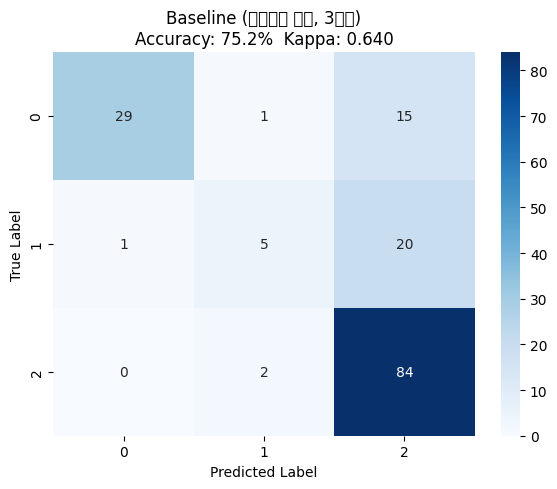


=== 클래스별 Recall ===
  클래스 0: 64.4%  ████████████
  클래스 1: 19.2%  ███
  클래스 2: 97.7%  ███████████████████


In [1]:
# ============================================================
#  로지스틱 회귀 베이스라인 (3분류)
#  0=이탈없음 / 1=약한불만 / 2=이탈위험(기존 2+3 병합)
# ============================================================

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, accuracy_score
)
import matplotlib.pyplot as plt
import seaborn as sns

LABEL_NAMES = ["0-이탈없음", "1-약한불만", "2-이탈위험"]

# ── 1. 데이터 로드 & 라벨 병합 ──────────────────────────────
train_df = pd.read_csv("train.csv")   # 원본 train (증강 전)
test_df  = pd.read_csv("test.csv")

# 클래스 3 → 2로 병합 (KcELECTRA와 동일 기준)
train_df["label"] = train_df["label"].replace({3: 2})
test_df["label"]  = test_df["label"].replace({3: 2})

print("=== 클래스 분포 (병합 후) ===")
print("train:")
print(train_df["label"].value_counts().sort_index())
print("test:")
print(test_df["label"].value_counts().sort_index())

X_train = train_df["clean_review"].fillna("")
X_test  = test_df["clean_review"].fillna("")
y_train = train_df["label"]
y_test  = test_df["label"]


# ── 2. TF-IDF 벡터화 ─────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000)
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)


# ── 3. 로지스틱 회귀 학습 ────────────────────────────────────
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",   # class weight 동일하게 적용
    random_state=42
)
model.fit(X_train_vec, y_train)


# ── 4. 테스트 평가 ───────────────────────────────────────────
y_pred = model.predict(X_test_vec)

acc   = accuracy_score(y_test, y_pred)
kappa = cohen_kappa_score(y_test, y_pred, weights="quadratic")

print(f"\n{'='*40}")
print(f"  Test Accuracy  : {acc*100:.1f}%")
print(f"  Quadratic Kappa: {kappa:.4f}")
print(f"{'='*40}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

# 혼동 행렬
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["0","1","2"],
            yticklabels=["0","1","2"], ax=ax)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title(f"Baseline (로지스틱 회귀, 3분류)\nAccuracy: {acc*100:.1f}%  Kappa: {kappa:.3f}")
plt.tight_layout()
plt.savefig("confusion_matrix_baseline_3class.png", dpi=150)
plt.show()

# 클래스별 Recall
print("\n=== 클래스별 Recall ===")
for i in range(3):
    mask   = np.array(y_test) == i
    recall = (np.array(y_pred)[mask] == i).mean() if mask.sum() > 0 else 0
    bar    = "█" * int(recall * 20)
    print(f"  클래스 {i}: {recall:.1%}  {bar}")